## SINGLE-CELL PROCESSING

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import h5py

In [2]:
adata = sc.read_h5ad('adata.h5ad')
adata.var_names_make_unique()  

In [3]:
adata

AnnData object with n_obs × n_vars = 42512 × 29733
    obs: 'celltype_major', 'subtype'
    var: 'gene_ids', 'feature_types'

In [4]:
sc.pp.filter_cells(adata, min_genes=3)
sc.pp.filter_genes(adata, min_cells=400)

In [5]:
adata

AnnData object with n_obs × n_vars = 42512 × 14076
    obs: 'celltype_major', 'subtype', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'

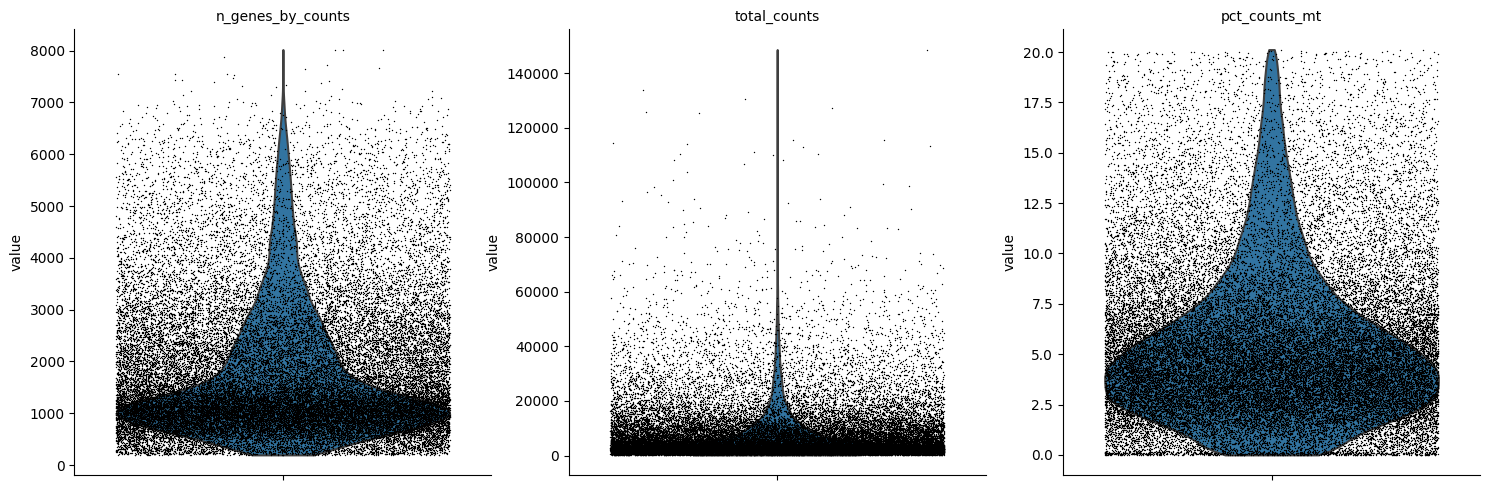

In [6]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],jitter=0.4, multi_panel=True)

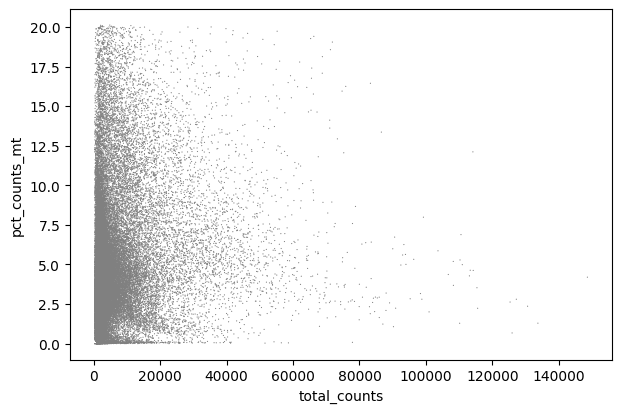

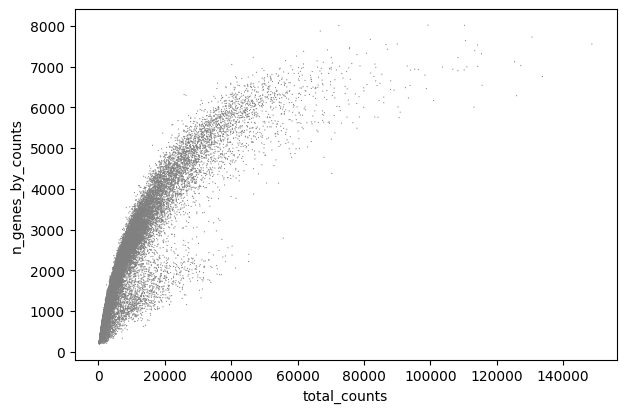

In [7]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [8]:
# adata = adata[adata.obs.n_genes_by_counts < 8000, :]
# adata = adata[adata.obs.pct_counts_mt < 20 , :]

In [9]:
adata

AnnData object with n_obs × n_vars = 42512 × 14076
    obs: 'celltype_major', 'subtype', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [10]:
adata.raw = adata.copy()

In [11]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,flavor='seurat')

In [12]:
adata

AnnData object with n_obs × n_vars = 42512 × 14076
    obs: 'celltype_major', 'subtype', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [13]:
#Get adata with integer counts
subset = adata.raw.to_adata()
subset = subset[:, adata.var.highly_variable]

In [14]:
subset

View of AnnData object with n_obs × n_vars = 42512 × 2197
    obs: 'celltype_major', 'subtype', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'hvg'

In [15]:
adata = adata[:, adata.var.highly_variable]

In [16]:
adata

View of AnnData object with n_obs × n_vars = 42512 × 2197
    obs: 'celltype_major', 'subtype', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

### Single cell and bulk processing

In [17]:
bulk = pd.read_csv('bulk.csv', index_col=0, delimiter=",").T

In [18]:
bulk.shape

(1194, 55402)

In [19]:
bulk_genes = bulk.columns.to_numpy()
sc_gene = adata.var.gene_ids.values
inter = np.intersect1d(bulk_genes, sc_gene) ##

In [20]:
len(inter)

2038

In [21]:
pd.DataFrame(inter).to_csv("./../../DATA/BREAST/inter.csv", header=None, index=False)

In [22]:
adata = adata[:, adata.var['gene_ids'].isin(inter)]

In [23]:
subset = subset[:, subset.var['gene_ids'].isin(inter)]

In [24]:
subset

View of AnnData object with n_obs × n_vars = 42512 × 2038
    obs: 'celltype_major', 'subtype', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'hvg'

In [25]:
bulk = bulk.filter(items=inter)

In [28]:
fn = './../../DATA/BREAST/adata.h5ad'
subset.write_h5ad(fn,compression='gzip')